In [4]:
%pip install --no-deps -e /mnt/c/Github/sealwatch --force-reinstall
# %pip install opencv-python numpy scipy jpeglib h5py pandas pillow timm tqdm
# %pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu

Obtaining file:///mnt/c/Github/sealwatch
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sealwatch (pyproject.toml) ... done
  Created wheel for sealwatch: filename=sealwatch-2025.9-cp38-abi3-linux_x86_64.whl size=14761 sha256=258edbe27af3ba00017afd91687baf04c38290f5a7e4c3dcf775c7a2cde21b61
  Stored in directory: /tmp/pip-ephem-wheel-cache-2o_go56z/wheels/09/64/7a/ddca0d00d3d96e147011b583fa244989ab4f61075225ce6855
Successfully built sealwatch
  Attempting uninstall: sealwatch
    Found existing installation: sealwatch 2025.9
    Uninstalling sealwatch-2025.9:
      Successfully uninstalled sealwatch-2025.9
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import os


def load_img(name, perc, method):
    if method == "cover":
        base_path = "../../data/boss_cover/"
    else:
        base_path = "../data/" + method + "/" + str(round(perc * 100))

    img_path = os.path.join(base_path, str(name) + ".png")

    with Image.open(img_path) as img:

        image_array = np.array(img.convert("L"))
    return image_array

In [2]:
from sealwatch.cost_estimator import attack
import pandas as pd
from pathlib import Path
import numpy as np
from PIL import Image
import os

data_dir = Path("../data")

# alle stego-methoden = alle unterordner außer "cover"
skip_methods = ["cover", "jpeg"]  # , "hill", "hugo", "lsbm", "lsbr"]
methods = [
    d.name
    for d in data_dir.iterdir()
    if d.is_dir() and d.name not in skip_methods
]
skip_alphas = []  # ["10", "15", "25", "35", "60"]
limit_images = 5


csv_path = "results.csv"
df = pd.DataFrame()

rows = []

for method in methods:
    print("Method: ", method)
    method_dir = data_dir / method
    for alpha_dir in method_dir.iterdir():
        print("Alpha: ", alpha_dir)
        if not alpha_dir.is_dir():
            continue

        if alpha_dir.name in skip_alphas:
            continue
        alpha = int(alpha_dir.name) / 100  # "30" → 0.3

        image_ids = [f.stem for f in alpha_dir.glob("*.png")]

        for image_id in image_ids[:limit_images]:
            cover = load_img(image_id, alpha, "cover")
            stego = load_img(image_id, alpha, method)
            results = attack(stego, cover)
            # print("image: ", image_id)
            # for e in sorted(results["all"], key=lambda x: x["log_lik"], reverse=True):
            #    print(e)
            rows.append(
                {
                    "image_id": image_id,
                    "alpha": alpha,
                    "true_method": method,
                    "pred_method": results["method"],
                    "pred_M": results["M"],
                }
            )

            # print(f"method={method} alpha={alpha} image={image_id} → pred={results["method"]}, M={results["M"]}")

df = pd.concat([df, pd.DataFrame(rows)], ignore_index=True)
df.to_csv(csv_path, index=False)
print(f"Saved to {csv_path}")

/home/feierabe/venv_info_projekt/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Method:  hill
Alpha:  ../data/hill/10
Alpha:  ../data/hill/100
Alpha:  ../data/hill/15
Alpha:  ../data/hill/20
Alpha:  ../data/hill/25
Alpha:  ../data/hill/30
Alpha:  ../data/hill/35
Alpha:  ../data/hill/40
Alpha:  ../data/hill/45
Alpha:  ../data/hill/50
Alpha:  ../data/hill/60
Alpha:  ../data/hill/70
Alpha:  ../data/hill/80
Alpha:  ../data/hill/90
Method:  hugo
Alpha:  ../data/hugo/10
Alpha:  ../data/hugo/100
Alpha:  ../data/hugo/15
Alpha:  ../data/hugo/20
Alpha:  ../data/hugo/25
Alpha:  ../data/hugo/30
Alpha:  ../data/hugo/35
Alpha:  ../data/hugo/40
Alpha:  ../data/hugo/45
Alpha:  ../data/hugo/50
Alpha:  ../data/hugo/60
Alpha:  ../data/hugo/70
Alpha:  ../data/hugo/80
Alpha:  ../data/hugo/90
Method:  lsbm
Alpha:  ../data/lsbm/10
Alpha:  ../data/lsbm/100
Alpha:  ../data/lsbm/15
Alpha:  ../data/lsbm/20
Alpha:  ../data/lsbm/25
Alpha:  ../data/lsbm/30
Alpha:  ../data/lsbm/35
Alpha:  ../data/lsbm/40
Alpha:  ../data/lsbm/45
Alpha:  ../data/lsbm/50
Alpha:  ../data/lsbm/60
Alpha:  ../data/lsb

Loaded: 2520 rows
Overall accuracy: 99.29%


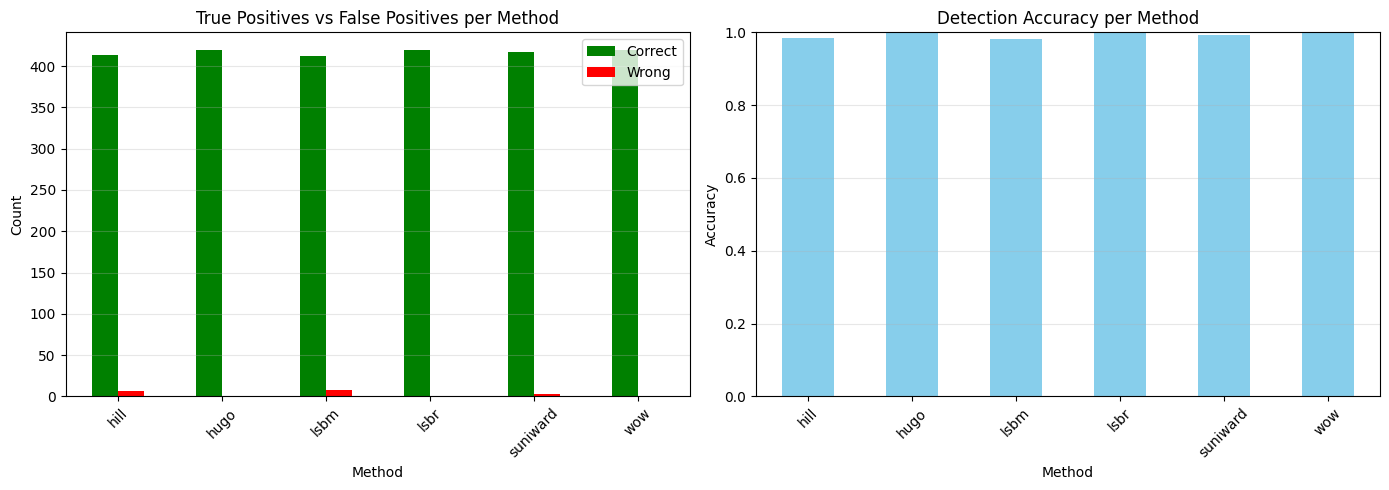

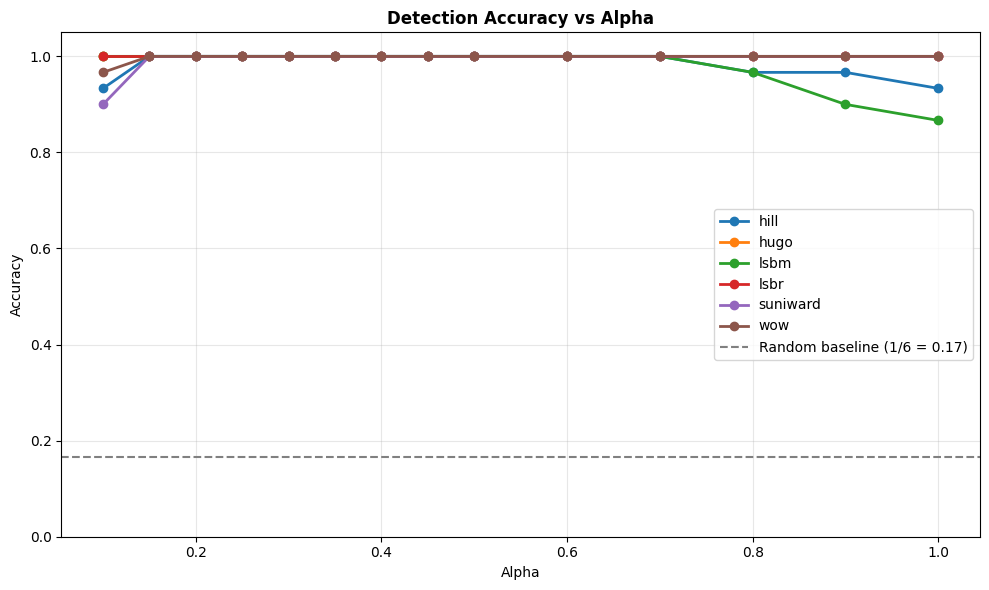

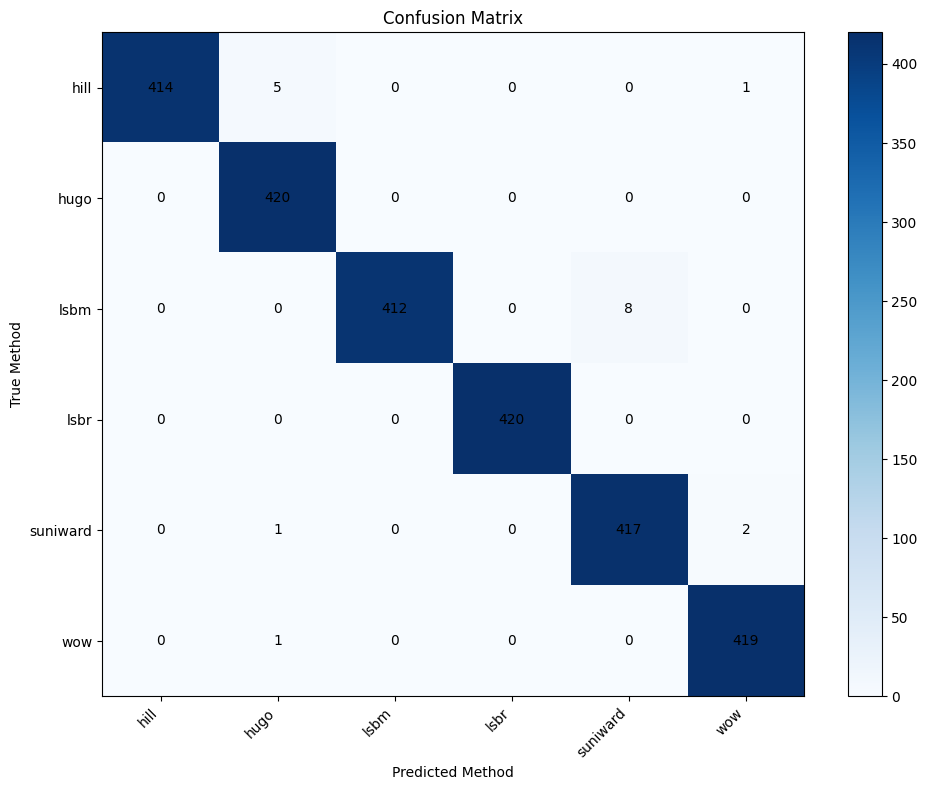


Summary:
              TP  Total  Accuracy  FP
true_method                          
hill         414    420  0.985714   6
hugo         420    420  1.000000   0
lsbm         412    420  0.980952   8
lsbr         420    420  1.000000   0
suniward     417    420  0.992857   3
wow          419    420  0.997619   1


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

path = "./results/test_friday_11/"
csv_file = path + "results.csv"

if not Path(csv_file).exists():
    print(f"File not found: {csv_file}")
    exit()

df = pd.read_csv(csv_file)
df["alpha"] = pd.to_numeric(df["alpha"], errors="coerce")
df["correct"] = (df["pred_method"] == df["true_method"]).astype(int)

print(f"Loaded: {len(df)} rows")
print(f"Overall accuracy: {df['correct'].mean():.2%}")

# --- Plot 1: TP vs FP per method ---
accuracy = df.groupby("true_method")["correct"].agg(["sum", "count", "mean"])
accuracy.columns = ["TP", "Total", "Accuracy"]
accuracy["FP"] = accuracy["Total"] - accuracy["TP"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

accuracy[["TP", "FP"]].plot(kind="bar", ax=ax1, color=["green", "red"])
ax1.set_xlabel("Method")
ax1.set_ylabel("Count")
ax1.set_title("True Positives vs False Positives per Method")
ax1.legend(["Correct", "Wrong"])
ax1.grid(True, alpha=0.3, axis="y")
ax1.tick_params(axis="x", rotation=45)

accuracy["Accuracy"].plot(kind="bar", ax=ax2, color="skyblue")
ax2.set_xlabel("Method")
ax2.set_ylabel("Accuracy")
ax2.set_title("Detection Accuracy per Method")
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3, axis="y")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(path + "results_tp_fp.png", dpi=300)
plt.show()

# --- Plot 2: Accuracy vs Alpha ---
fig, ax = plt.subplots(figsize=(10, 6))

for method in sorted(df["true_method"].unique()):
    method_data = df[df["true_method"] == method]
    acc_by_alpha = method_data.groupby("alpha")["correct"].mean()
    ax.plot(
        acc_by_alpha.index,
        acc_by_alpha.values,
        marker="o",
        label=method,
        linewidth=2,
    )

ax.set_xlabel("Alpha")
ax.set_ylabel("Accuracy")
ax.set_title("Detection Accuracy vs Alpha", fontweight="bold")
ax.set_ylim([0, 1.05])
ax.legend()
ax.grid(True, alpha=0.3)

n_methods = df["true_method"].nunique()
random_accuracy = 1 / n_methods
ax.axhline(
    random_accuracy,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label=f"Random baseline (1/{n_methods} = {random_accuracy:.2f})",
)
ax.legend()

plt.tight_layout()
plt.savefig(path + "results_accuracy_vs_alpha.png", dpi=300)
plt.show()


# --- Plot 3: Confusion Matrix ---
cm = pd.crosstab(df["true_method"], df["pred_method"])

# ensure all methods appear on both axes
all_methods = sorted(set(df["true_method"]) | set(df["pred_method"]))
cm = cm.reindex(index=all_methods, columns=all_methods, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm.values, cmap="Blues", aspect="auto")

ax.set_xticks(range(len(cm.columns)))
ax.set_yticks(range(len(cm.index)))
ax.set_xticklabels(cm.columns, rotation=45, ha="right")
ax.set_yticklabels(cm.index)
ax.set_xlabel("Predicted Method")
ax.set_ylabel("True Method")
ax.set_title("Confusion Matrix")

for i in range(len(cm.index)):
    for j in range(len(cm.columns)):
        ax.text(j, i, cm.values[i, j], ha="center", va="center", color="black")

plt.colorbar(im)
plt.tight_layout()
plt.savefig(path + "results_confusion_matrix.png", dpi=300)
plt.show()

print("\nSummary:")
print(accuracy)

             M_error_abs  M_error_rel
true_method                          
hill          320.727791     0.011139
hugo          180.297697     0.008029
lsbm          717.485166     0.015868
lsbr          180.096190     0.007676
suniward      236.843579     0.012889
wow           181.652602     0.008200


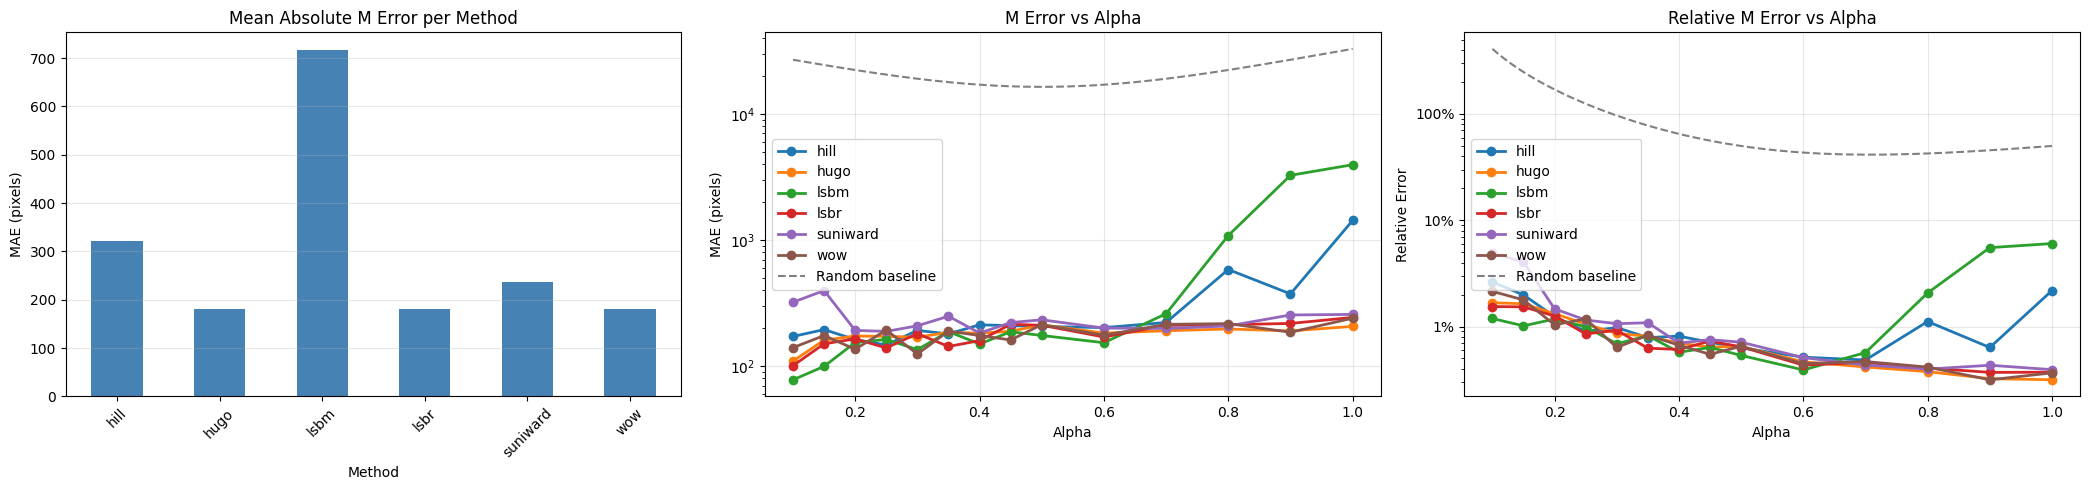

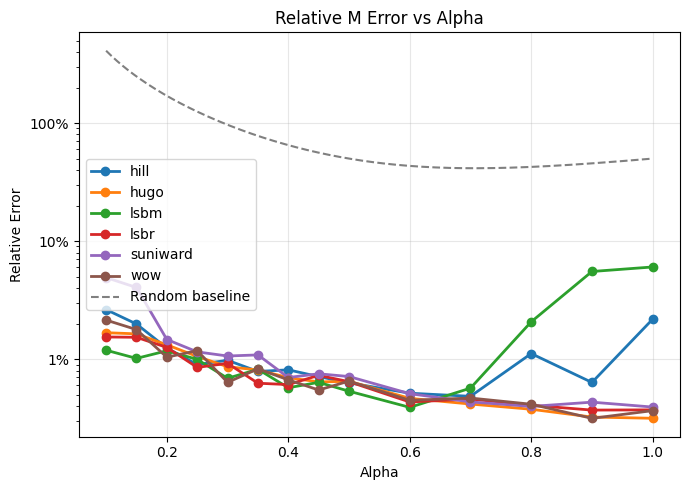

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

if not Path(csv_file).exists():
    print(f"File not found: {csv_file}")
    exit()

df = pd.read_csv(csv_file)
df["alpha"] = pd.to_numeric(df["alpha"], errors="coerce")

# true_M: alpha * image size (256x256)
df["true_M"] = df["alpha"] * 256 * 256
df["M_error"] = df["pred_M"] - df["true_M"]
df["M_error_abs"] = df["M_error"].abs()
df["M_error_rel"] = df["M_error_abs"] / df["true_M"]

print(df.groupby("true_method")[["M_error_abs", "M_error_rel"]].mean())

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Mean absolute M error per method
df.groupby("true_method")["M_error_abs"].mean().plot(
    kind="bar", ax=axes[0], color="steelblue"
)
axes[0].set_title("Mean Absolute M Error per Method")
axes[0].set_xlabel("Method")
axes[0].set_ylabel("MAE (pixels)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, alpha=0.3, axis="y")

# M error vs alpha per method
for method in sorted(df["true_method"].unique()):
    d = df[df["true_method"] == method].groupby("alpha")["M_error_abs"].mean()
    axes[1].plot(d.index, d.values, marker="o", label=method, linewidth=2)

axes[1].set_title("M Error vs Alpha")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("MAE (pixels)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Relative M error vs alpha per method
for method in sorted(df["true_method"].unique()):
    d = df[df["true_method"] == method].groupby("alpha")["M_error_rel"].mean()
    axes[2].plot(d.index, d.values, marker="o", label=method, linewidth=2)

axes[2].set_title("Relative M Error vs Alpha")
axes[2].set_xlabel("Alpha")
axes[2].set_ylabel("Relative Error")
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[2].legend()
axes[2].grid(True, alpha=0.3)


alpha_range = np.linspace(df["alpha"].min(), df["alpha"].max(), 200)
n = 256 * 256

baseline_mae = (2 * alpha_range**2 - 2 * alpha_range + 1) / 2 * n
baseline_rel = (2 * alpha_range**2 - 2 * alpha_range + 1) / (2 * alpha_range)

axes[1].plot(
    alpha_range,
    baseline_mae,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Random baseline",
)
axes[1].legend()

axes[2].plot(
    alpha_range,
    baseline_rel,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Random baseline",
)
axes[2].legend()

axes[1].set_yscale("log")
axes[2].set_yscale("log")
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.savefig(path + "results_M_error.png", dpi=300)
plt.show()

# --- Relative M Error extra ---
fig2, ax = plt.subplots(figsize=(7, 5))
for method in sorted(df["true_method"].unique()):
    d = df[df["true_method"] == method].groupby("alpha")["M_error_rel"].mean()
    ax.plot(d.index, d.values, marker="o", label=method, linewidth=2)
ax.plot(
    alpha_range,
    baseline_rel,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Random baseline",
)
ax.set_title("Relative M Error vs Alpha")
ax.set_xlabel("Alpha")
ax.set_ylabel("Relative Error")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend()
ax.grid(True, alpha=0.3)
fig2.tight_layout()
fig2.savefig(path + "results_M_error_rel.png", dpi=300)
plt.show()

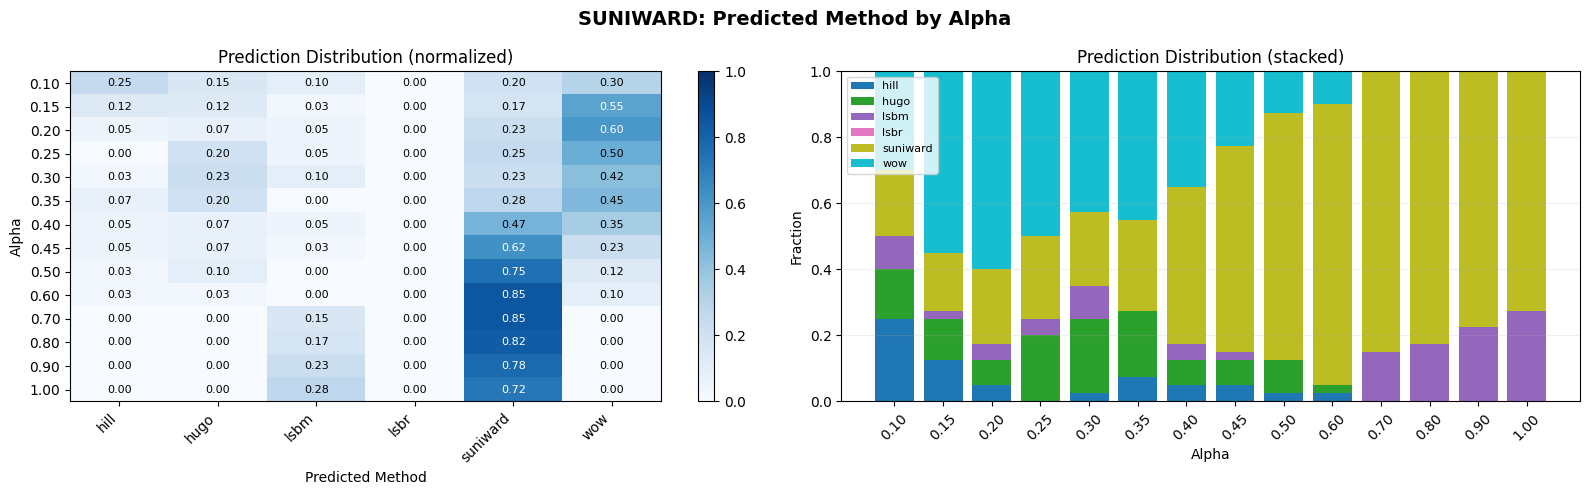

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

path = "./results/40images/"
csv_file = path + "results.csv"

df = pd.read_csv(csv_file)
df["alpha"] = pd.to_numeric(df["alpha"], errors="coerce")

# Only SUNIWARD rows
sun = df[df["true_method"] == "suniward"].copy()

alphas = sorted(sun["alpha"].unique())
all_methods = sorted(df["pred_method"].unique())

# Build matrix: rows = alpha, cols = predicted method
counts = pd.crosstab(sun["alpha"], sun["pred_method"])
counts = counts.reindex(columns=all_methods, fill_value=0)

# Normalize per alpha (row)
counts_norm = counts.div(counts.sum(axis=1), axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    "SUNIWARD: Predicted Method by Alpha", fontsize=14, fontweight="bold"
)

# --- Left: heatmap (normalized) ---
im = ax1.imshow(
    counts_norm.values, cmap="Blues", aspect="auto", vmin=0, vmax=1
)
ax1.set_xticks(range(len(counts_norm.columns)))
ax1.set_xticklabels(counts_norm.columns, rotation=45, ha="right")
ax1.set_yticks(range(len(counts_norm.index)))
ax1.set_yticklabels([f"{a:.2f}" for a in counts_norm.index])
ax1.set_xlabel("Predicted Method")
ax1.set_ylabel("Alpha")
ax1.set_title("Prediction Distribution (normalized)")

for i in range(len(counts_norm.index)):
    for j in range(len(counts_norm.columns)):
        val = counts_norm.values[i, j]
        ax1.text(
            j,
            i,
            f"{val:.2f}",
            ha="center",
            va="center",
            color="white" if val > 0.5 else "black",
            fontsize=8,
        )

plt.colorbar(im, ax=ax1)

# --- Right: stacked bar ---
bottom = np.zeros(len(alphas))
colors = plt.cm.tab10(np.linspace(0, 1, len(all_methods)))

for j, method in enumerate(all_methods):
    vals = (
        counts_norm[method].values
        if method in counts_norm.columns
        else np.zeros(len(alphas))
    )
    ax2.bar(
        range(len(alphas)), vals, bottom=bottom, label=method, color=colors[j]
    )
    bottom += vals

ax2.set_xticks(range(len(alphas)))
ax2.set_xticklabels([f"{a:.2f}" for a in alphas], rotation=45)
ax2.set_xlabel("Alpha")
ax2.set_ylabel("Fraction")
ax2.set_title("Prediction Distribution (stacked)")
ax2.set_ylim(0, 1)
ax2.legend(loc="upper left", fontsize=8)
ax2.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.savefig(path + "suniward_confusion_by_alpha.png", dpi=300)
plt.show()